In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
from faker import Faker
faker=Faker()
data=[]
for _ in range(250):
    data.append({
        "Date":faker.date(),
        "open_price":faker.random_int(50,10000),
        "cloe_price":faker.random_int(50,10000),
        "volume":faker.random_int(10,1000)
    })
    df=pd.DataFrame(data)
    df.to_csv("Stock_Market.csv")
    


In [5]:
df.head()

,Date,open_price,cloe_price,volume
0,2007-08-05,9139,5200,788
1,1999-01-01,2148,7462,754
2,1994-06-27,8472,673,35
3,2011-05-20,740,7829,980
4,2001-06-11,894,9408,862


In [8]:
df['daily_return']=df['cloe_price'].pct_change()
df.head()

,Date,open_price,cloe_price,volume,daily-returns,daily_return
0,2007-08-05,9139,5200,788,NaN,NaN
1,1999-01-01,2148,7462,754,0.435000,0.435000
2,1994-06-27,8472,673,35,-0.909810,-0.909810
3,2011-05-20,740,7829,980,10.632987,10.632987
4,2001-06-11,894,9408,862,0.201686,0.201686


In [10]:
df['rolling_volatility'] = df['daily_return'].rolling(window=20).std()
df.head()

,Date,open_price,cloe_price,volume,daily-returns,daily_return,rolling_volatility
0,2007-08-05,9139,5200,788,NaN,NaN,NaN
1,1999-01-01,2148,7462,754,0.435000,0.435000,NaN
2,1994-06-27,8472,673,35,-0.909810,-0.909810,NaN
3,2011-05-20,740,7829,980,10.632987,10.632987,NaN
4,2001-06-11,894,9408,862,0.201686,0.201686,NaN


In [13]:
last_price = df['cloe_price'].iloc[-1]

simulated_prices = []
price = last_price

for _ in range(30):
    simulated_return = np.random.normal(df['daily_return'].mean(),
                                        df['daily_return'].std())
    price = price * (1 + simulated_return)
    simulated_prices.append(price)
    
simulated_prices

[np.float64(-3197.3173636726674),
 np.float64(-23681.830282250197),
 np.float64(-84814.13732313055),
 np.float64(-25462.604331919258),
 np.float64(2661.840582119537),
 np.float64(11911.543179785138),
 np.float64(64009.71868662756),
 np.float64(-175566.08843776418),
 np.float64(383277.06891120336),
 np.float64(3013100.0151707404),
 np.float64(23243953.483097687),
 np.float64(72301181.36516787),
 np.float64(130262698.43415526),
 np.float64(349778877.8667966),
 np.float64(3701950547.193511),
 np.float64(-12027418687.769136),
 np.float64(-28249567866.255566),
 np.float64(62675119939.735504),
 np.float64(134761900546.98984),
 np.float64(-277818540835.1469),
 np.float64(-2890027120222.8164),
 np.float64(409833741246.1104),
 np.float64(1161806213966.145),
 np.float64(-124665526151.3058),
 np.float64(-450959071756.11896),
 np.float64(1032524904346.2944),
 np.float64(2652581349619.3965),
 np.float64(12268119370179.887),
 np.float64(41824803945578.63),
 np.float64(12975928312683.86)]

In [14]:
v = np.std(df['daily_return'])
v

np.float64(4.032207123468005)

In [15]:
a = np.percentile(df['daily_return'], 5)
a

np.float64(nan)

In [16]:
s = df['daily_return'].mean() / df['daily_return'].std()
s

np.float64(0.29448717460681967)

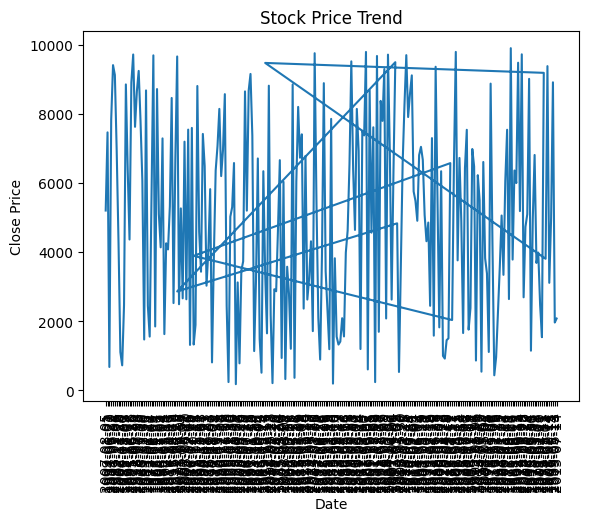

In [22]:
plt.figure()
plt.plot(df['Date'], df['cloe_price'])
plt.title("Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=90)
plt.show()